# **TASK3.3 CLUSTERING**

<span style="color: blue;"> Problem Statement
Dino Tim wants to start a farming business but accidentally mixed seeds of different crops.  
The objective of this task is to cluster the given seed data into meaningful groups using **K-Means clustering**.
</span>
<span style="color: blue;"> 
Since the data is **unlabeled**, an **unsupervised learning approach** is used.  
The optimal number of clusters is determined using evaluation techniques, and **PCA is applied only for visualization purposes**.
</span>
<span style="color: blue;"> 
Target label information is used **only after clustering** for evaluation and visualization.
</span>

## Import Important Libraraies

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Loading And Understanding The Dataset

In [2]:
# Load the dataset
data = pd.read_csv("seeds_data.csv")  

In [3]:
data.head()


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


<span style="color: blue;">The dataset consists of multiple numerical features representing physical
characteristics of seeds. The goal is to cluster these samples into meaningful
groups without using the target labels.</span>


In [4]:
data.shape


(210, 8)

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  210 non-null    float64
 1   Feature_2  210 non-null    float64
 2   Feature_3  210 non-null    float64
 3   Feature_4  210 non-null    float64
 4   Feature_5  210 non-null    float64
 5   Feature_6  210 non-null    float64
 6   Feature_7  210 non-null    float64
 7   Class      210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [6]:
data.describe()


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [7]:
data.isnull().sum()


Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Feature_6    0
Feature_7    0
Class        0
dtype: int64

**Data Understanding**

<span style="color: blue;">
    
The dataset contains **210 samples** and **8 columns**.  
Out of these, **7 columns (Feature_1 to Feature_7)** represent numerical features
describing physical characteristics of seeds, while **1 column (Class)** represents
the true seed category.
</span>

<span style="color: blue;">
    
Key observations:
- All feature columns are **numeric**.
- The target column **Class** is of type **int64**.
- There are **no missing values** in the dataset.
- Feature ranges vary significantly across columns, indicating that
  **feature scaling is required** before applying K-Means clustering.
</span>

<span style="color: blue;">
    
Since this is an unsupervised learning task, the `Class` column will **not be used**
during clustering and will be used **only for post-clustering evaluation and visualization**.
</span>

## Data Preprocessing

In [8]:
# Separate input features and target labels
X = data.drop(columns=['Class'])
y = data['Class']   

In [9]:
X.head(), y.head()


(   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  Feature_7
 0      15.26      14.84     0.8710      5.763      3.312      2.221      5.220
 1      14.88      14.57     0.8811      5.554      3.333      1.018      4.956
 2      14.29      14.09     0.9050      5.291      3.337      2.699      4.825
 3      13.84      13.94     0.8955      5.324      3.379      2.259      4.805
 4      16.14      14.99     0.9034      5.658      3.562      1.355      5.175,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: Class, dtype: int64)

**Feature Scaling**

<span style="color: blue;">
    
K-Means is a distance-based clustering algorithm.  
Therefore, feature scaling is essential to ensure that all features contribute
equally to the distance calculations.
</span>

<span style="color: blue;">
    
In this task, **standardization** is applied so that each feature has:
- Mean = 0
- Standard Deviation = 1
</span>

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
# Check scaled data (first 5 rows)
X_scaled[:5]


array([[ 1.42097769e-01,  2.15462437e-01,  6.06017918e-05,
         3.04218199e-01,  1.41701823e-01, -9.86151745e-01,
        -3.83577423e-01],
       [ 1.11880257e-02,  8.22375713e-03,  4.28515270e-01,
        -1.68624664e-01,  1.97432229e-01, -1.78816620e+00,
        -9.22013487e-01],
       [-1.92066576e-01, -3.60200562e-01,  1.44238325e+00,
        -7.63637453e-01,  2.08047544e-01, -6.67479334e-01,
        -1.18919199e+00],
       [-3.47091272e-01, -4.75333162e-01,  1.03938133e+00,
        -6.88978054e-01,  3.19508356e-01, -9.60817955e-01,
        -1.22998260e+00],
       [ 4.45257175e-01,  3.30595037e-01,  1.37450924e+00,
         6.66655647e-02,  8.05159035e-01, -1.56349549e+00,
        -4.75356297e-01]])

## Choosing the Optimal Number of Clusters (K)

### Elbow Method


<span style="color: blue;">
The elbow method helps identify an optimal value of K by observing the
within-cluster sum of squares (inertia) for different values of K.
</span>
<span style="color: blue;">
As K increases, inertia decreases. The point where the rate of decrease
significantly slows down (forming an "elbow") is considered a good choice for K.
</span>

In [14]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


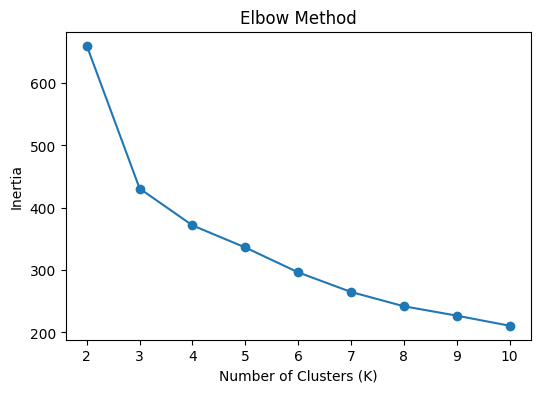

In [15]:
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### Silhouette Score


<span style="color: blue;">
The silhouette score measures how well data points are clustered by considering
both intra-cluster cohesion and inter-cluster separation.
</span>
<span style="color: blue;">
    
Silhouette values range from -1 to 1:
    
- Values close to 1 indicate well-separated clusters
  
- Values close to 0 indicate overlapping clusters
  
- Negative values indicate incorrect clustering
  
</span>

In [16]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)


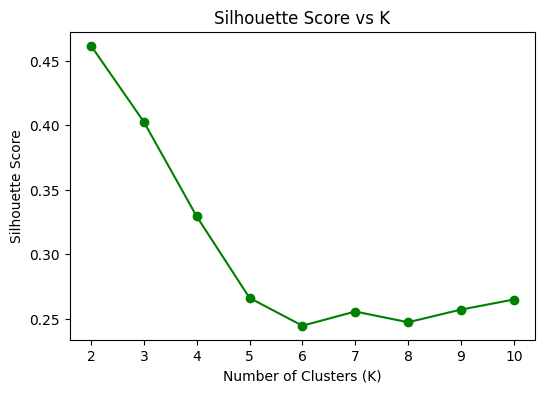

In [17]:
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()


### Selection of optimal K

<span style="color: blue;">
    
Based on the evaluation using both the **Elbow Method** and the **Silhouette Score**, 
the following observations were made:

- From the **Elbow Method**, a sharp decrease in inertia is observed from K = 2 to K = 3,
  after which the rate of decrease becomes more gradual. This suggests that increasing
  the number of clusters beyond K = 3 wont provide better results , also **k=3** shows elbow bend.

- From the **Silhouette Score analysis**, the highest silhouette value is obtained at
  **K = 2**, indicating the strongest separation between clusters at this value.
  However, **K = 3** also shows a reasonably good silhouette score while allowing for
  a more meaningful partitioning of the data.

Considering both, **K = 3** is selected as the optimal
number of clusters for further analysis.
</span>

<span style="color: red;"> Note: A train–test split is not performed since K-Means is an unsupervised learning
algorithm and does not require generalization evaluation on unseen labels. </span>

## Implementing K-Means FROM SCRATCH

<span style="color: blue;"> In this section, K-Means clustering is implemented **from scratch** using NumPy.</span>

<span style="color: blue;"> 
The algorithm follows these steps:

1. Initialize K cluster centers

2. Assign each data point to the nearest cluster center

3. Update cluster centers as the mean of assigned points

4. Repeat until convergence or maximum iterations are reached
</span>

### Step 1. Initialization of Cluster Centers


In [33]:
# Set number of clusters
K = 3

np.random.seed(42)

# Randomly choose K data points as initial centers
random_indices = np.random.choice(X_scaled.shape[0], K, replace=False)
centers = X_scaled[random_indices]

centers


array([[-0.58135081, -0.56743924, -0.20356142, -0.39486527, -0.7526385 ,
        -1.89676816, -0.71806043],
       [-1.23245454, -1.21985731, -1.2343979 , -1.22290588, -1.31525021,
         0.40587335, -0.83227414],
       [ 1.6062199 ,  1.65078218,  0.29700938,  1.66844904,  1.43942413,
        -0.49214284,  1.58456955]])

### Step 2 Assignment Step (Distance + Cluster Allocation)

In [34]:
def assign_clusters(X, centers):
    """
    Assign each data point to the nearest cluster center.
    Parameters:
    X : ndarray of shape (n_samples, n_features)
    centers : ndarray of shape (K, n_features)
    
    Returns:
    labels : ndarray of shape (n_samples,)
    """
    labels = []
    
    for x in X:
        # Compute distance from point x to each center
        distances = np.linalg.norm(x - centers, axis=1)
        
        # Assign to the closest center
        labels.append(np.argmin(distances))
    
    return np.array(labels)


In [35]:
labels = assign_clusters(X_scaled, centers)
labels[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 2, 2])

### Step 3. Update Step (Recomputing Cluster Centers)

In [36]:
def update_centers(X, labels, K):
    """
    Update cluster centers as the mean of assigned points.
    Parameters:
    X : ndarray of shape (n_samples, n_features)
    labels : ndarray of shape (n_samples,)
    K : int (number of clusters)
    Returns:
    new_centers : ndarray of shape (K, n_features)
    """
    new_centers = []
    
    for k in range(K):
        # Select points belonging to cluster k
        cluster_points = X[labels == k]
        
        # Compute mean of cluster points
        center = cluster_points.mean(axis=0)
        new_centers.append(center)
    
    return np.array(new_centers)


In [37]:
new_centers = update_centers(X_scaled, labels, K)
new_centers


array([[-0.20209305, -0.22891503,  0.37571031, -0.31963183, -0.06177159,
        -0.80413652, -0.65812259],
       [-1.00111367, -0.98308925, -0.88884143, -0.88455049, -1.04854041,
         0.7981119 , -0.61140998],
       [ 1.20592139,  1.21295398,  0.5468168 ,  1.19863334,  1.12160009,
        -0.05051986,  1.24106665]])

### Step 4: Iterative Optimization and Convergence


<span style="color: blue;">
The assignment and update steps are repeated iteratively until the algorithm
converges. Convergence is achieved when the cluster centers stop changing
significantly or when a maximum number of iterations is reached. </span>

In [ ]:
def kmeans_from_scratch(X, K, max_iters=100, tol=1e-4):
    """
    K-Means clustering implemented from scratch.
    
    Parameters:
    X : ndarray of shape (n_samples, n_features)
    K : int
    max_iters : int
    tol : float (tolerance for center movement) ( IT'ss IMP ???)
    ]
    
    Returns:
    centers : ndarray of shape (K, n_features)
    labels : ndarray of shape (n_samples,)
    """
    np.random.seed(42)
    
    # Initialize centers randomly
    random_indices = np.random.choice(X.shape[0], K, replace=False)
    centers = X[random_indices]
    
    for iteration in range(max_iters):
        # Assignment step
        labels = assign_clusters(X, centers)
        
        # Update step
        new_centers = update_centers(X, labels, K)
        
        # Check convergence (center movement)
        center_shift = np.linalg.norm(new_centers - centers)
        
        if center_shift < tol:
            print(f"Converged at iteration {iteration}")
            break
        
        centers = new_centers
    
    return centers, labels


In [24]:
final_centers, cluster_labels = kmeans_from_scratch(X_scaled, K=3)


Converged at iteration 4


In [25]:
np.unique(cluster_labels, return_counts=True)


(array([0, 1, 2]), array([73, 68, 69]))

## Interpretation of Cluster Centers


<span style="color: blue;"> 
    
After fitting the K-Means model, the resulting cluster centers are obtained
in the **scaled feature space**. To interpret them meaningfully, the centers
are transformed back to the **original feature scale**.
</span>

In [26]:
# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(final_centers)

# Create a DataFrame for better readability
centers_df = pd.DataFrame(
    centers_original,
    columns=X.columns
)

centers_df


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7
0,14.286438,14.264932,0.880912,5.486904,3.243562,2.667236,5.087548
1,11.837206,13.241618,0.847613,5.233426,2.842544,4.880338,5.115235
2,18.407826,16.169275,0.883557,6.167754,3.684551,3.630014,6.035768


<span style="color: blue;">Each row in the table above represents the **average feature values** of a
cluster, effectively describing a typical seed belonging to that cluster.
</span>

<span style="color: blue;">
By comparing the feature values across clusters, we can observe differences
in seed characteristics such as size, shape, and compactness.
</span>

### Intuitive Interpretation of Clusters


The cluster centers represent the average physical characteristics of seeds
belonging to each cluster. By comparing feature values across clusters, we can
derive the following insights:

- **Cluster 0** shows moderate values across most features. The seed dimensions
  (Feature_1, Feature_2, Feature_4, and Feature_7) are neither the smallest nor
  the largest among the clusters, indicating a group of **medium-sized seeds**
  with balanced physical properties.

- **Cluster 1** is characterized by comparatively lower values for size-related
  features such as Feature_1, Feature_2, Feature_4, and Feature_5. This suggests
  that this cluster corresponds to **smaller and more compact seeds**. However,
  Feature_6 shows a relatively higher value, indicating a distinct internal
  characteristic that differentiates this group from the others.

- **Cluster 2** exhibits the highest values for most size-related features,
  including Feature_1, Feature_2, Feature_4, Feature_5, and Feature_7. This
  indicates that this cluster represents **larger seeds with greater area and
  perimeter**, making it clearly separable from the other clusters.

Overall, the differences in cluster centers suggest that K-Means has effectively
grouped the mixed seed samples into distinct categories based on their physical
measurements.



## PCA Visualization of Clusters


<span style="color: blue;">
    
To visualize the clustering results, Principal Component Analysis (PCA) is
applied to project the high-dimensional data into two dimensions.

PCA is used **only for visualization purposes** and does not influence the
clustering process.
</span>

In [27]:
# Apply PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [28]:
X_pca.shape


(210, 2)

### Visualization of Clusters in PCA Space


<span style="color: blue;">
The clustered data points are visualized in a two-dimensional PCA space.
Each point is colored based on its assigned cluster, and the cluster centers
are also projected and displayed for reference.
</span>

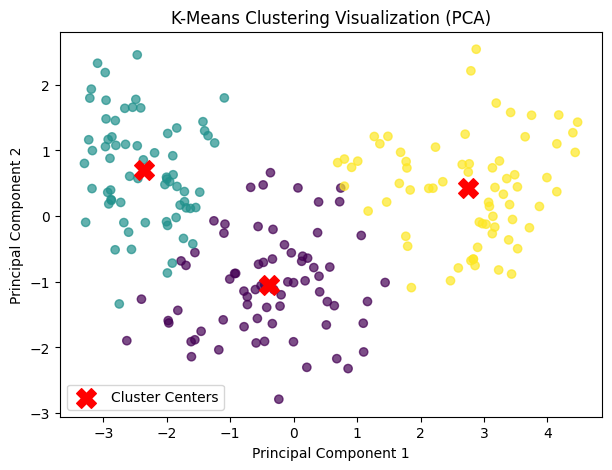

In [29]:
# Project cluster centers to PCA space
centers_pca = pca.transform(final_centers)

plt.figure(figsize=(7, 5))

# Scatter plot of data points
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.7
)

# Plot cluster centers
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Cluster Centers'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering Visualization (PCA)')
plt.legend()
plt.show()


## Post-Clustering Evaluation


<span style="color: blue;">
    
Although K-Means is an unsupervised algorithm, the dataset contains true class
labels. These labels are used **only after clustering** to evaluate how well the
formed clusters correspond to the actual seed categories.
</span>

In [30]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True_Class': y,
    'Cluster_Assigned': cluster_labels
})

comparison_df.head()


,True_Class,Cluster_Assigned
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [31]:
pd.crosstab(comparison_df['True_Class'],
            comparison_df['Cluster_Assigned'])


Cluster_Assigned,0,1,2
True_Class,,,
1,65,3,2
2,3,0,67
3,5,65,0


### Evaluation Interpretation


The contingency table shows a strong correspondence between the clusters formed
by K-Means and the true seed classes.

- **Cluster 0** is dominated by samples from **Class 1**, with very few samples
  from other classes.
- **Cluster 1** predominantly contains samples from **Class 3**, indicating a
  clear separation of this seed type.
- **Cluster 2** is almost exclusively composed of samples from **Class 2**.

This strong one-to-one correspondence between clusters and true classes indicates
that K-Means has successfully captured the underlying structure of the data.
Minor overlaps are expected due to similarities in physical characteristics
between certain seed types.


Overall, each cluster is dominated by a specific class, indicating high cluster
purity. Minor overlaps are expected due to the unsupervised nature of the
algorithm and similarities between certain seed types.


Silhouette score is used to compare clustering quality across different K values within the same experiment, not to compare absolute scores across different runs or individuals.”

## Conclusion


<span style="color: blue;">
    
In this task, K-Means clustering was successfully implemented **from scratch** to
group mixed seed samples into meaningful clusters.

The optimal number of clusters was determined using a combination of the
**Elbow Method** and **Silhouette Score**, ensuring a balance between cluster
compactness and separation. Based on this analysis, K = 3 was selected.

The resulting cluster centers were analyzed and interpreted in the original
feature space, revealing clear differences in physical seed characteristics
across clusters. PCA was applied **only for visualization purposes**, allowing
the clustering structure to be observed in two dimensions.

Finally, post-clustering evaluation using the true class labels showed a strong
correspondence between clusters and actual seed categories, indicating high
cluster purity and effective separation.

Overall, this task demonstrates the effective application of unsupervised
learning techniques, from data preprocessing and algorithm implementation to
evaluation and interpretation.
</span>